In [1]:
# -*- coding: utf-8 -*-


from sklearn import neighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import model_selection
import pandas as pd
import numpy as np

/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps, copy_X=True, fit_path=True,
/anac

In [2]:
def question2Regression():
    
    # Load regression dataset into NumPy array
    data  = np.genfromtxt("DataLab9/regressionExample.csv", delimiter=",")
    
    # Split the dataset into 20% test and 80% training data
    features = data[:,:-1]
    targets = data[:,-1]
    train_features, test_features, train_targets, test_targets = model_selection.train_test_split( features, targets, test_size=0.2)
    
    # Create an instance of a K Nearest Neighbour regression algorithm and assess it's accuracy
    # with default hyper-parameter settings
    reg = KNeighborsRegressor()
    reg = reg.fit(train_features, train_targets)
    print (reg.score(test_features, test_targets)) 

In [4]:
def question3Outliers():
    
    # Load training and test data into NumPY arrays
    trainData = np.genfromtxt("DataLab9/outliersData/trainOutlier.csv", delimiter = ",")
    testData = np.genfromtxt("DataLab9/outliersData/test.csv", delimiter = ",")
    
    # Extract feature and target labels
    train_features = trainData[:,:-1]
    train_labels = trainData[:,-1]
    
    test_features = testData[:,:-1]
    test_labels = testData[:,-1]    

    # Generate a boxplot to identify possible outliers
    sns.boxplot(data= pd.DataFrame(train_features))
    plt.show()    

    # Assess the R2 score for a decision tree regression model 
    # on the data before removal of outliers
    reg = DecisionTreeRegressor()
    reg = reg.fit(train_features, train_labels)
    print (reg.score(test_features, test_labels)) 
        
    rowsToDelete = train_features[:,0]<7.5
    train_features = train_features[rowsToDelete]
    train_labels = train_labels[rowsToDelete]
        
        
    rowsToDelete = train_features[:,1] > -5
    train_features = train_features[rowsToDelete]
    train_labels = train_labels[rowsToDelete]
        
    rowsToDelete = train_features[:,2] < 5
    train_features = train_features[rowsToDelete]
    train_labels = train_labels[rowsToDelete]
        
    rowsToDelete = train_features[:,6] < 7
    train_features = train_features[rowsToDelete]
    train_labels = train_labels[rowsToDelete]
    
    # Generate boxplot after outlier removal
    sns.boxplot(data= pd.DataFrame(train_features))
    plt.show()
    
    # Assess the R2 score of a regression tree after removal of outliers
    reg = DecisionTreeRegressor()
    reg = reg.fit(train_features, train_labels)
    print (reg.score(test_features, test_labels)) 

0.9999671748758429


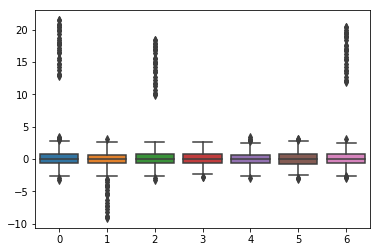

0.639522279375576


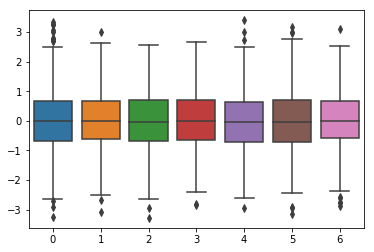

0.6885363597426924


In [7]:
def main():

    
    question2Regression()
    
    question3Outliers()

main()